In [60]:
! pip install langgraph chromadb sentence-transformers pydantic

**Module D "We deploy the model. Two weeks later, France issues a new ID card format, and our accuracy there drops to 0%. How do you architect the system to handle 'Format Drift' without requiring a full model retrain every week?"**

In [61]:
from google.colab import drive,userdata
drive.mount('/content/drive/')
client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [62]:
import base64
import json
import re
from datetime import datetime
from typing import TypedDict, Optional, Dict, Any, List

import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction
from langgraph.graph import StateGraph, END
from openai import OpenAI
from pydantic import BaseModel, Field

In [63]:
# =====================================================
# 1. State
# =====================================================

class KYCState(TypedDict):
    image_path: str

    country: Optional[str]
    document_type: Optional[str]
    template: Optional[Dict[str, Any]]

    extracted_fields: Optional[Dict[str, Any]]
    rule_validation: Optional[Dict[str, Any]]

    confidence_score: Optional[float]
    drift_detected: Optional[bool]

    decision: Optional[str]
    reason_codes: List[str]

In [64]:
# =====================================================
# 2. Pydantic Structured Output
# =====================================================

class ExtractedField(BaseModel):
    value: Optional[str] = Field(default=None)
    confidence: float = Field(ge=0, le=1)
    evidence: str


In [65]:
class KYCExtraction(BaseModel):
    country: ExtractedField
    document_type: ExtractedField
    nik: Optional[ExtractedField] = None
    full_name: Optional[ExtractedField] = None
    date_of_birth: Optional[ExtractedField] = None
    place_of_birth: Optional[ExtractedField] = None
    address: Optional[ExtractedField] = None
    nationality: Optional[ExtractedField] = None
    expiry_date: Optional[ExtractedField] = None

In [66]:
# =====================================================
# 3. ChromaDB Template Registry
# =====================================================

embedding_fn = SentenceTransformerEmbeddingFunction(
    model_name="all-MiniLM-L6-v2"
)

chroma_client = chromadb.PersistentClient(path="./chroma_kyc_template_db")

template_collection = chroma_client.get_or_create_collection(
    name="kyc_template_registry",
    embedding_function=embedding_fn
)


def seed_template_registry():
    if template_collection.count() > 0:
        return

    templates = [
        {
            "id": "ID_KTP_2026_V1",
            "document": """
            Country: Indonesia
            Document Type: KTP / Indonesian National Identity Card
            Keywords: NIK, Nama, Tempat/Tgl Lahir, Jenis Kelamin, Alamat,
            RT/RW, Kel/Desa, Kecamatan, Agama, Status Perkawinan,
            Pekerjaan, Kewarganegaraan, Berlaku Hingga, WNI.
            Required Fields: nik, full_name, date_of_birth, address,
            nationality, expiry_date.
            NIK is usually 16 digits.
            Nationality usually appears as WNI.
            Expiry date may appear as SEUMUR HIDUP.
            """,
            "metadata": {
                "country": "Indonesia",
                "document_type": "KTP",
                "template_version": "ID_KTP_2026_V1",
                "required_fields": "nik,full_name,date_of_birth,address,nationality,expiry_date",
                "document_number_field": "nik",
                "document_number_regex": "^[0-9]{16}$"
            }
        },
        {
            "id": "IN_PASSPORT_2025_V1",
            "document": """
            Country: India
            Document Type: Passport
            Keywords: Republic of India, Passport, Surname, Given Name,
            Nationality, Date of Birth, Place of Birth, Passport No, Date of Expiry.
            Required Fields: full_name, date_of_birth, document_number,
            nationality, expiry_date.
            Passport number starts with one alphabet followed by seven digits.
            """,
            "metadata": {
                "country": "India",
                "document_type": "Passport",
                "template_version": "IN_PASS_2025_V1",
                "required_fields": "full_name,date_of_birth,document_number,nationality,expiry_date",
                "document_number_field": "document_number",
                "document_number_regex": "^[A-Z][0-9]{7}$"
            }
        },
        {
            "id": "FR_NATIONAL_ID_2026_V2",
            "document": """
            Country: France
            Document Type: National ID
            Keywords: Republique Francaise, Carte Nationale D'identite,
            Nom, Prenoms, Date de Naissance, Numero Document, Expiration.
            Required Fields: full_name, date_of_birth, document_number, expiry_date.
            """,
            "metadata": {
                "country": "France",
                "document_type": "National ID",
                "template_version": "FR_ID_2026_V2",
                "required_fields": "full_name,date_of_birth,document_number,expiry_date",
                "document_number_field": "document_number",
                "document_number_regex": "^[A-Z0-9]{9,12}$"
            }
        }
    ]

    template_collection.add(
        ids=[t["id"] for t in templates],
        documents=[t["document"] for t in templates],
        metadatas=[t["metadata"] for t in templates]
    )


seed_template_registry()

In [67]:
# =====================================================
# 4. OpenAI Client
# =====================================================

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))


def encode_image(image_path: str) -> str:
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

In [68]:
# =====================================================
# 5. Country + Document Type Detector using Vision LLM
# =====================================================

def country_document_detector(state: KYCState) -> KYCState:
    image_base64 = encode_image(state["image_path"])

    response = client.responses.parse(
        model="gpt-4.1-mini",
        input=[
            {
                "role": "system",
                "content": "You are a document classification AI for global KYC."
            },
            {
                "role": "user",
                "content": [
                    {
                        "type": "input_text",
                        "text": """
Identify the country and document type from this identity document image.

Return only:
- country
- document_type

Examples:
Indonesia KTP
India Passport
France National ID

Do not guess. If unclear, return null with low confidence.
"""
                    },
                    {
                        "type": "input_image",
                        "image_url": f"data:image/jpeg;base64,{image_base64}"
                    }
                ]
            }
        ],
        text_format=KYCExtraction
    )

    parsed = response.output_parsed

    state["country"] = parsed.country.value
    state["document_type"] = parsed.document_type.value
    state["reason_codes"].append("COUNTRY_DOCUMENT_DETECTED_BY_VISION_LLM")

    return state

In [69]:
# =====================================================
# 6. Template Registry / Layout Store using ChromaDB
# =====================================================

def template_registry_lookup(state: KYCState) -> KYCState:
    query = f"""
    Country: {state["country"]}
    Document Type: {state["document_type"]}
    identity document template layout fields validation rules
    """

    results = template_collection.query(
        query_texts=[query],
        n_results=1
    )

    if not results["ids"][0]:
        state["template"] = None
        state["reason_codes"].append("TEMPLATE_NOT_FOUND")
        return state

    state["template"] = {
        "template_id": results["ids"][0][0],
        "template_text": results["documents"][0][0],
        "metadata": results["metadatas"][0][0]
    }

    state["reason_codes"].append(
        f"TEMPLATE_FOUND_{state['template']['metadata']['template_version']}"
    )

    return state

In [70]:
# =====================================================
# 7. LLM Vision Field Extraction
# =====================================================

def llm_vision_field_extraction(state: KYCState) -> KYCState:
    image_base64 = encode_image(state["image_path"])
    template = state["template"]

    prompt = f"""
You are a KYC Vision Extraction AI.

Use this template information:

{template["template_text"] if template else "No template found"}

Return ONLY valid JSON.
Do not hallucinate.
If a value is not clearly visible, return null.

Extract ONLY:
  - country
  - document_type
  - nik
  - full_name
  - date_of_birth
  - place_of_birth
  - address
  - nationality
  - expiry_date

Rules:
1. id_number must come from NIK or any 16 digits number in the Id card.
2. full_name must come from Nama.
3. date_of_birth must come from Tempat/Tgl Lahir, it follow DD-MM-YYYY.
4. address must come from Alamat.
5. nationality must come from Kewarganegaraan.
6. expiry_date must come from Berlaku Hingga.
7. date_of_birth must be YYYY-MM-DD.
8. Do not include extra fields.
9. Do not wrap JSON inside markdown.
10.Do not return ```json.

Return STRICT JSON only with the above schema and must not return extra strings:
"""

    response = client.responses.parse(
        model="gpt-4.1",
        temperature =0,
        top_p =1,
        input=[
            {
                "role": "system",
                "content": "You are a strict KYC document extraction AI. Never guess."
            },
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": prompt},
                    {
                        "type": "input_image",
                        "image_url": f"data:image/jpeg;base64,{image_base64}"
                    }
                ]
            }
        ],
        text_format=KYCExtraction
    )

    result = response.output_parsed.model_dump()
    state["extracted_fields"] = result
    state["reason_codes"].append("LLM_VISION_FIELDS_EXTRACTED")

    return state

In [71]:
# =====================================================
# 8. Country-Specific Rule Engine
# =====================================================

def country_specific_rule_engine(state: KYCState) -> KYCState:
    errors = []
    template = state["template"]
    fields = state["extracted_fields"]

    if template is None:
        errors.append("NO_TEMPLATE_FOUND")
    else:
        metadata = template["metadata"]
        required_fields = metadata["required_fields"].split(",")

        for field in required_fields:
            field_obj = fields.get(field)
            if not field_obj or not field_obj.get("value"):
                errors.append(f"MISSING_FIELD_{field.upper()}")

        doc_field = metadata.get("document_number_field")
        regex = metadata.get("document_number_regex")

        if doc_field and regex:
            doc_obj = fields.get(doc_field)
            doc_value = doc_obj.get("value") if doc_obj else None

            if doc_value and not re.match(regex, doc_value):
                errors.append(f"INVALID_{doc_field.upper()}_FORMAT")

        expiry_obj = fields.get("expiry_date")
        expiry_value = expiry_obj.get("value") if expiry_obj else None

        if expiry_value:
            if expiry_value.upper() not in ["SEUMUR HIDUP", "LIFETIME"]:
                try:
                    expiry_date = datetime.strptime(expiry_value, "%Y-%m-%d")
                    if expiry_date < datetime.now():
                        errors.append("DOCUMENT_EXPIRED")
                except Exception:
                    errors.append("INVALID_EXPIRY_DATE_FORMAT")

    state["rule_validation"] = {
        "passed": len(errors) == 0,
        "errors": errors
    }

    if errors:
        state["reason_codes"].extend(errors)
    else:
        state["reason_codes"].append("COUNTRY_RULES_PASSED")

    return state

In [72]:
# =====================================================
# 9. Confidence + Drift Monitor
# =====================================================

def confidence_and_drift_monitor(state: KYCState) -> KYCState:
    fields = state["extracted_fields"]

    confidence_values = []

    for key, value in fields.items():
        if isinstance(value, dict) and value.get("confidence") is not None:
            confidence_values.append(value["confidence"])

    avg_confidence = (
        sum(confidence_values) / len(confidence_values)
        if confidence_values else 0
    )

    state["confidence_score"] = round(avg_confidence, 4)

    drift_detected = False

    if state["template"] is None:
        drift_detected = True

    if avg_confidence < 0.80:
        drift_detected = True

    if state["rule_validation"] and len(state["rule_validation"]["errors"]) >= 2:
        drift_detected = True

    state["drift_detected"] = drift_detected

    if drift_detected:
        state["reason_codes"].append("POSSIBLE_FORMAT_DRIFT_DETECTED")
    else:
        state["reason_codes"].append("NO_FORMAT_DRIFT")

    return state

In [73]:
# =====================================================
# 10. Decision Engine
# =====================================================

def decision_engine(state: KYCState) -> KYCState:
    confidence = state["confidence_score"]
    rules_passed = state["rule_validation"]["passed"]
    drift = state["drift_detected"]

    if drift:
        state["decision"] = "MANUAL_REVIEW"
        state["reason_codes"].append("ROUTED_TO_MANUAL_REVIEW_DUE_TO_DRIFT")

    elif confidence >= 0.90 and rules_passed:
        state["decision"] = "APPROVED"
        state["reason_codes"].append("AUTO_APPROVED")

    elif confidence >= 0.70:
        state["decision"] = "MANUAL_REVIEW"
        state["reason_codes"].append("LOW_CONFIDENCE_MANUAL_REVIEW")

    else:
        state["decision"] = "REJECTED"
        state["reason_codes"].append("LOW_CONFIDENCE_REJECTED")

    return state

In [74]:
# =====================================================
# 11. Manual Review / Feedback Loop
# =====================================================

def feedback_loop(state: KYCState) -> KYCState:
    if state["decision"] == "MANUAL_REVIEW":
        state["reason_codes"].append("SENT_TO_MANUAL_REVIEW_QUEUE")
        state["reason_codes"].append("SAVED_FOR_CONTINUOUS_LEARNING")
    elif state["decision"] == "APPROVED":
        state["reason_codes"].append("SAVED_SUCCESS_CASE_FOR_MONITORING")
    else:
        state["reason_codes"].append("SAVED_REJECTION_CASE_FOR_AUDIT")

    return state

In [75]:
# =====================================================
# 12. LangGraph Flow
# =====================================================

workflow = StateGraph(KYCState)

workflow.add_node("country_document_detector", country_document_detector)
workflow.add_node("template_registry_lookup", template_registry_lookup)
workflow.add_node("llm_vision_field_extraction", llm_vision_field_extraction)
workflow.add_node("country_specific_rule_engine", country_specific_rule_engine)
workflow.add_node("confidence_and_drift_monitor", confidence_and_drift_monitor)
workflow.add_node("decision_engine", decision_engine)
workflow.add_node("feedback_loop", feedback_loop)

workflow.set_entry_point("country_document_detector")

workflow.add_edge("country_document_detector", "template_registry_lookup")
workflow.add_edge("template_registry_lookup", "llm_vision_field_extraction")
workflow.add_edge("llm_vision_field_extraction", "country_specific_rule_engine")
workflow.add_edge("country_specific_rule_engine", "confidence_and_drift_monitor")
workflow.add_edge("confidence_and_drift_monitor", "decision_engine")
workflow.add_edge("decision_engine", "feedback_loop")
workflow.add_edge("feedback_loop", END)

app = workflow.compile()

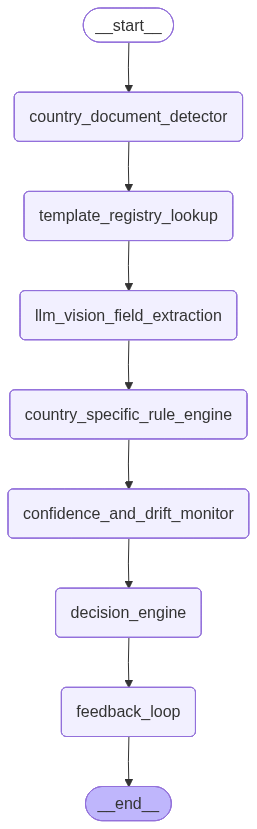

In [76]:
app

**
# =====================================================
# Positive Usecase
# =====================================================
**

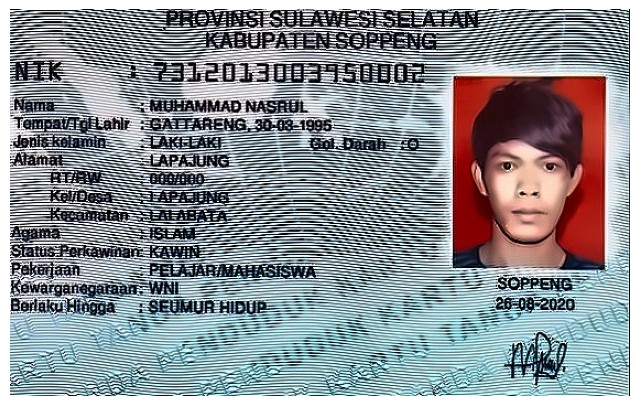

In [77]:
import matplotlib.pyplot as plt

image_path = "/content/drive/My Drive/kyc_train/after_preprocess_image/clean/4affbc3d-ktp-51_jpg.rf.776aae5096657885ebc42d71159aa2bd.jpg"

# Read image
image = cv2.imread(image_path)

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(8,6))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [78]:
# =====================================================
# Sample Run for Positive Usecase
# =====================================================

if __name__ == "__main__":

    initial_state: KYCState = {
        "image_path": "/content/drive/My Drive/kyc_train/after_preprocess_image/clean/4affbc3d-ktp-51_jpg.rf.776aae5096657885ebc42d71159aa2bd.jpg",

        "country": None,
        "document_type": None,
        "template": None,

        "extracted_fields": None,
        "rule_validation": None,

        "confidence_score": None,
        "drift_detected": None,

        "decision": None,
        "reason_codes": []
    }

    result = app.invoke(initial_state)

    print(json.dumps(result, indent=2, ensure_ascii=False))

{
  "image_path": "/content/drive/My Drive/kyc_train/after_preprocess_image/clean/4affbc3d-ktp-51_jpg.rf.776aae5096657885ebc42d71159aa2bd.jpg",
  "country": "Indonesia",
  "document_type": "KTP",
  "template": {
    "template_id": "ID_KTP_2026_V1",
    "template_text": "\n            Country: Indonesia\n            Document Type: KTP / Indonesian National Identity Card\n            Keywords: NIK, Nama, Tempat/Tgl Lahir, Jenis Kelamin, Alamat,\n            RT/RW, Kel/Desa, Kecamatan, Agama, Status Perkawinan,\n            Pekerjaan, Kewarganegaraan, Berlaku Hingga, WNI.\n            Required Fields: nik, full_name, date_of_birth, address,\n            nationality, expiry_date.\n            NIK is usually 16 digits.\n            Nationality usually appears as WNI.\n            Expiry date may appear as SEUMUR HIDUP.\n            ",
    "metadata": {
      "document_number_regex": "^[0-9]{16}$",
      "template_version": "ID_KTP_2026_V1",
      "required_fields": "nik,full_name,date_of_bi

**
# =====================================================
# Failure Usecase/ Drift Detections:
# =====================================================
**

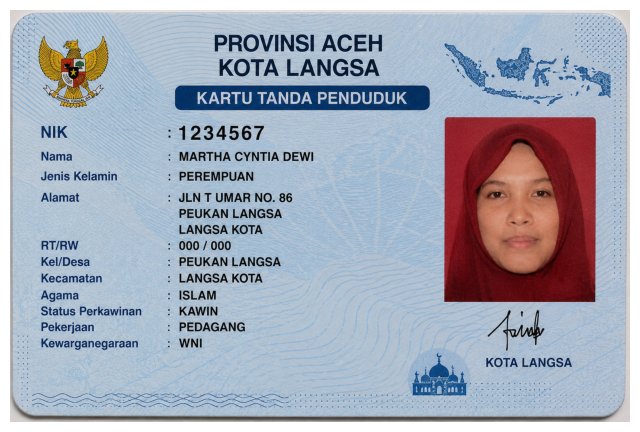

In [81]:
import matplotlib.pyplot as plt

image_path = "/content/drive/My Drive/kyc_train/Drift_Detection/drift_detection.png"

# Read image
image = cv2.imread(image_path)

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(8,6))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [82]:
# =====================================================
# Failure Usecase
# =====================================================

if __name__ == "__main__":

    initial_state: KYCState = {
        "image_path": "/content/drive/My Drive/kyc_train/Drift_Detection/drift_detection.png",

        "country": None,
        "document_type": None,
        "template": None,

        "extracted_fields": None,
        "rule_validation": None,

        "confidence_score": None,
        "drift_detected": None,

        "decision": None,
        "reason_codes": []
    }

    result = app.invoke(initial_state)

    print(json.dumps(result, indent=2, ensure_ascii=False))

{
  "image_path": "/content/drive/My Drive/kyc_train/Drift_Detection/drift_detection.png",
  "country": "Indonesia",
  "document_type": "KTP",
  "template": {
    "template_id": "ID_KTP_2026_V1",
    "template_text": "\n            Country: Indonesia\n            Document Type: KTP / Indonesian National Identity Card\n            Keywords: NIK, Nama, Tempat/Tgl Lahir, Jenis Kelamin, Alamat,\n            RT/RW, Kel/Desa, Kecamatan, Agama, Status Perkawinan,\n            Pekerjaan, Kewarganegaraan, Berlaku Hingga, WNI.\n            Required Fields: nik, full_name, date_of_birth, address,\n            nationality, expiry_date.\n            NIK is usually 16 digits.\n            Nationality usually appears as WNI.\n            Expiry date may appear as SEUMUR HIDUP.\n            ",
    "metadata": {
      "country": "Indonesia",
      "document_type": "KTP",
      "required_fields": "nik,full_name,date_of_birth,address,nationality,expiry_date",
      "template_version": "ID_KTP_2026_V1",
 

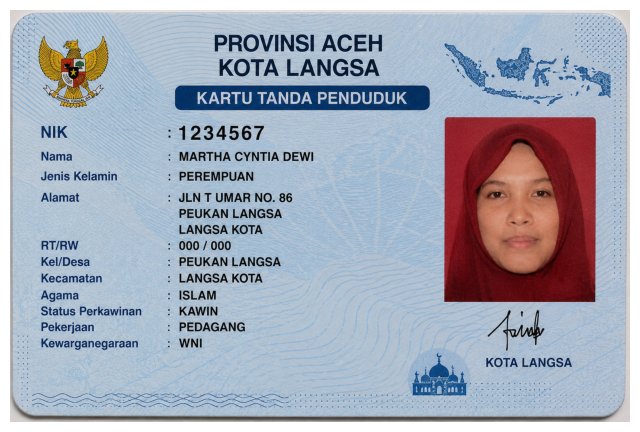

In [83]:
# Failure Use case 2

image_path = "/content/drive/My Drive/kyc_train/Drift_Detection/drift_detection_2.png"

# Read image
image = cv2.imread(image_path)

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(8,6))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [85]:
KYCState = {
        "image_path": "/content/drive/My Drive/kyc_train/Drift_Detection/drift_detection_2.png",

        "country": None,
        "document_type": None,
        "template": None,

        "extracted_fields": None,
        "rule_validation": None,

        "confidence_score": None,
        "drift_detected": None,

        "decision": None,
        "reason_codes": []
    }
result = app.invoke(initial_state)

print(json.dumps(result, indent=2, ensure_ascii=False))

{
  "image_path": "/content/drive/My Drive/kyc_train/Drift_Detection/drift_detection.png",
  "country": "Indonesia",
  "document_type": "KTP",
  "template": {
    "template_id": "ID_KTP_2026_V1",
    "template_text": "\n            Country: Indonesia\n            Document Type: KTP / Indonesian National Identity Card\n            Keywords: NIK, Nama, Tempat/Tgl Lahir, Jenis Kelamin, Alamat,\n            RT/RW, Kel/Desa, Kecamatan, Agama, Status Perkawinan,\n            Pekerjaan, Kewarganegaraan, Berlaku Hingga, WNI.\n            Required Fields: nik, full_name, date_of_birth, address,\n            nationality, expiry_date.\n            NIK is usually 16 digits.\n            Nationality usually appears as WNI.\n            Expiry date may appear as SEUMUR HIDUP.\n            ",
    "metadata": {
      "document_number_regex": "^[0-9]{16}$",
      "document_number_field": "nik",
      "document_type": "KTP",
      "template_version": "ID_KTP_2026_V1",
      "required_fields": "nik,full_